In [35]:
!pip install nbformat

#Multiple regression From Scratch

In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Dataset
X = np.array([
    [1, 2],
    [2, 1],
    [3, 3],
    [4, 5],
    [5, 4]
])

y = np.array([8, 7, 15, 23, 22])

# Model
model = LinearRegression()

# Train
model.fit(X, y)

# Coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# Prediction
new_data = np.array([[6, 3]])
print("Prediction:", model.predict(new_data))

# Accuracy
print("R2 Score:", model.score(X, y))

Intercept: 7.105427357601002e-15
Coefficients: [2. 3.]
Prediction: [21.]
R2 Score: 1.0


In [43]:
model.fit(X, y)

# Predict on training data
y_predict = model.predict(X)

print("Actual y:", y)
print("Predicted y:", y_predict)

Actual y: [ 8  7 15 23 22]
Predicted y: [ 8.  7. 15. 23. 22.]


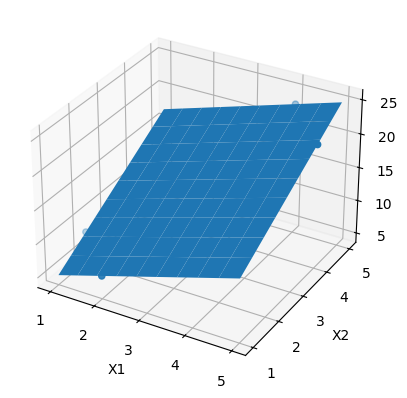

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

# Dataset
X = np.array([
    [1, 2],
    [2, 1],
    [3, 3],
    [4, 5],
    [5, 4]
])

y = np.array([8, 7, 15, 23, 22])

# Model
model = LinearRegression()
model.fit(X, y)

# Create 3D Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Scatter actual points
ax.scatter(X[:, 0], X[:, 1], y)

# Create grid for plane
x1_range = np.linspace(X[:,0].min(), X[:,0].max(), 10)
x2_range = np.linspace(X[:,1].min(), X[:,1].max(), 10)

x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# Predict z values (plane)
z = model.intercept_ + model.coef_[0]*x1_grid + model.coef_[1]*x2_grid

# Plot regression plane
ax.plot_surface(x1_grid, x2_grid, z)

# Labels
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("Y")

plt.show()

# 🌸 Multiple Linear Regression From Scratch (Theory + Formula)

---

## 🌸 Step 1: Basic Linear Model

For 2 inputs:

$$
y = b_0 + b_1 x_1 + b_2 x_2
$$

Where:

- $b_0$ → intercept  
- $b_1$ → weight of $x_1$  
- $b_2$ → weight of $x_2$

Goal:  
Find best $b_0, b_1, b_2$

---

## 🌸 Step 2: What Does "Best" Mean?

Predicted value:

$$
\hat{y} = b_0 + b_1 x_1 + b_2 x_2
$$

Error:

$$
\text{error} = y - \hat{y}
$$

To reduce error, we use Mean Squared Error (MSE):

$$
J = \frac{1}{n} \sum (y - \hat{y})^2
$$

We want to minimize $J$.

---

## 🌸 Step 3: Convert to Matrix Form

Instead of writing long equations, we use matrices.

### Input matrix:

$$
X =
\begin{bmatrix}
1 & x_{11} & x_{12} \\
1 & x_{21} & x_{22} \\
1 & x_{31} & x_{32}
\end{bmatrix}
$$

First column = 1 (for intercept)

### Beta matrix:

$$
\beta =
\begin{bmatrix}
b_0 \\
b_1 \\
b_2
\end{bmatrix}
$$

### Output vector:

$$
Y =
\begin{bmatrix}
y_1 \\
y_2 \\
y_3
\end{bmatrix}
$$

Prediction becomes:

$$
\hat{Y} = X\beta
$$

---

## 🌸 Step 4: Cost Function in Matrix Form

Error vector:

$$
E = Y - X\beta
$$

Cost function:

$$
J = (Y - X\beta)^T (Y - X\beta)
$$

We minimize this function.

---

## 🌸 Step 5: Take Derivative

Take derivative of $J$ with respect to $\beta$.

After solving using calculus:

$$
X^T X \beta = X^T Y
$$

This is called the **Normal Equation**.

---

## 🌸 Step 6: Solve for Beta

Multiply both sides by inverse of $X^T X$:

$$
(X^T X)^{-1}
$$

Final solution:

$$
\beta = (X^T X)^{-1} X^T Y
$$

---

# 🎯 Final Ready Formula

$$
\boxed{\beta = (X^T X)^{-1} X^T Y}
$$

This directly gives:

- $b_0$
- $b_1$
- $b_2$


---

## 🌸 Why Do We Use Inverse?

From equation:

$$
X^T X \beta = X^T Y
$$

To isolate $\beta$:

$$
\beta = (X^T X)^{-1} X^T Y
$$

Inverse cancels $X^T X$.

---

## 🌸 Final Understanding

Multiple Regression Model:

$$
y = b_0 + b_1 x_1 + b_2 x_2 + ... + b_n x_n
$$

Matrix form:

$$
Y = X\beta
$$

Best beta:

$$
\beta = (X^T X)^{-1} X^T Y
$$



In [2]:
import numpy as np

# -----------------------------
# Step 1: Create Dataset
# -----------------------------

# Two input features (x1, x2)
X = np.array([
    [1, 2],
    [2, 1],
    [3, 3],
    [4, 5],
    [5, 4]
])

# Output
y = np.array([8, 7, 15, 23, 22])


In [3]:
ones = np.ones((X.shape[0], 1))
X = np.hstack((ones, X))   # Now X becomes [1, x1, x2]


In [4]:
XT = X.T
beta = np.linalg.inv(XT @ X) @ XT @ y

In [6]:
beta

array([-3.28626015e-14,  2.00000000e+00,  3.00000000e+00])

In [5]:
print("b0 (intercept):", beta[0])
print("b1:", beta[1])
print("b2:", beta[2])

b0 (intercept): -3.2862601528904634e-14
b1: 2.000000000000001
b2: 3.000000000000001


In [9]:
x_new = np.array([1, 6, 3])   # 1 for intercept
y_pred = x_new @ beta #@ is used for matrix multiplication
# * is used for norma;l multiplication

print("Predicted value:", y_pred)


Predicted value: 20.999999999999975


In [8]:
y_all_pred = X @ beta
print("Predicted y values:", y_all_pred)

Predicted y values: [ 8.  7. 15. 23. 22.]
